In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Crear conexión a base de datos SQLite
engine = create_engine('sqlite:////Users/sruiz.gomez/Maestria/AprendizajeAutomatico/data_accidentes.sqlite3')


# 4. Tareas a desarrollar
## 4.1 Analisis exploratorio de los datos

### EDA Tabla *raw_accidentes*

In [3]:
raw_accidentes = pd.read_sql('SELECT * FROM raw_accidentes', con=engine, parse_dates=['TW'])

In [4]:
raw_accidentes.head()

,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,...,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570146,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,...,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,None,8,2017-07-20 08:00:00
1,-75.600280,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,...,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,None,16,2017-06-15 16:00:00
2,-75.584306,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,...,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,None,16,2017-07-02 16:00:00
3,-75.583062,6.239497,504355,1576853,06:29 PM,MIERCOLES,2017,Choque,CL 33 Norte CR 65,CL 033 065 000 00000,...,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,None,18,2017-03-29 18:00:00
4,-75.590193,6.260463,504356,1591283,08:10 PM,MIERCOLES,2017,Atropello,CL 50 CR 74,CL 050 074 000 00000,...,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,None,20,2017-07-26 20:00:00


In [5]:
raw_accidentes.columns

Index(['Lon', 'Lat', 'OBJECTID', 'RADICADO', 'HORA', 'Dia_sem', 'PERIODO',
       'CLASE', 'DIRECCION', 'DIRECCION_ENC', 'CBML', 'TIPO_GEOCOD',
       'GRAVEDAD', 'BARRIO', 'COMUNA', 'DISENO', 'Mes', 'Dia', 'FECHA',
       'MES_NOMBRE', 'Hora_num', 'TW'],
      dtype='object')

Lo que mas nos interesa en este momento es el momento y lugar del accidente, por lo que se va tomar en cuenta las variables que indiquen ubicación y momento del accidente.

#### Distribución temporal: accidentes por hora del día, día de la semana, mes

In [6]:
raw_accidentes[['Hora_num','Dia_sem','Mes']].isna().sum()

Hora_num    0
Dia_sem     0
Mes         0
dtype: int64

In [7]:
raw_accidentes['Hora_num'] = raw_accidentes['Hora_num'].astype(int)

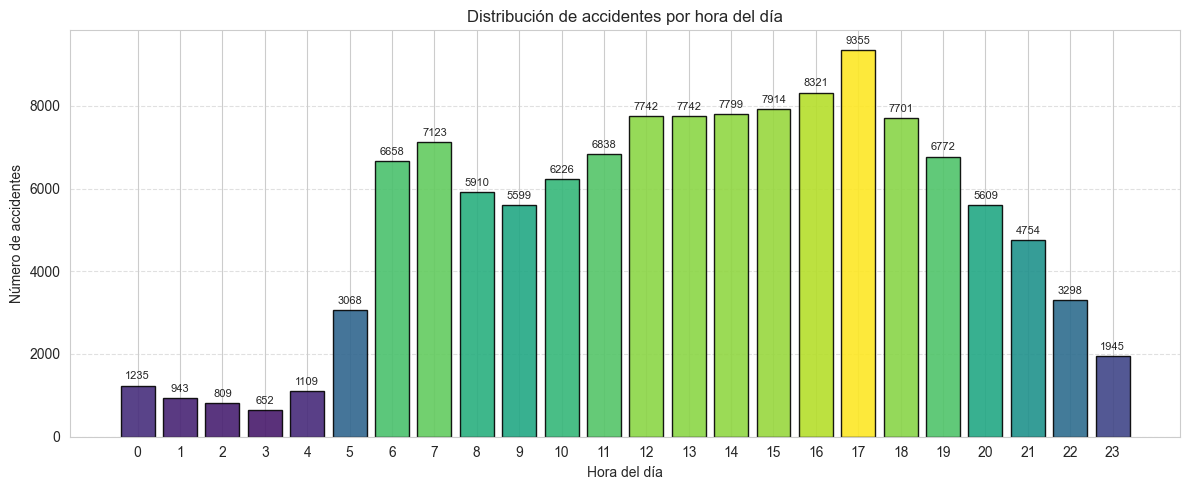

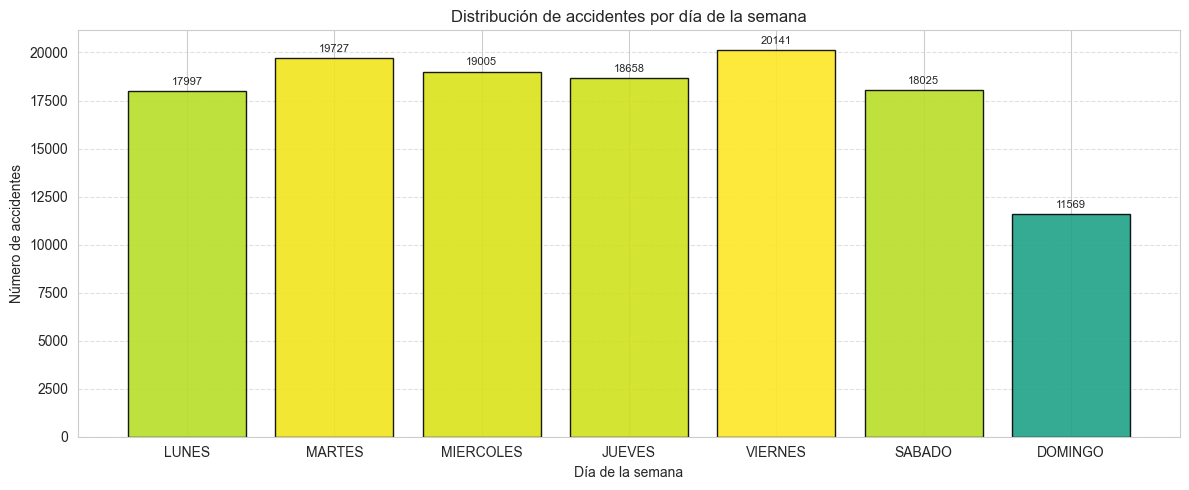

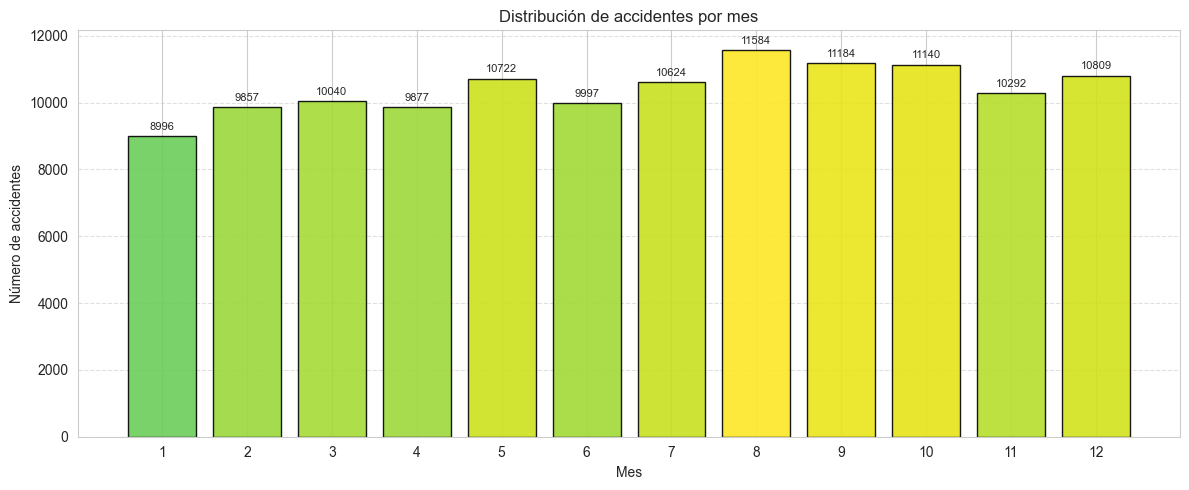

In [8]:
def plot_distribucion(df, columna, titulo, xlabel, orden=None, figsize=(12, 5)):
    counts = df[columna].value_counts()

    if orden is not None:
        counts = counts.reindex(orden, fill_value=0)
    else:
        counts = counts.sort_index()

    sns.set_style('whitegrid')
    plt.figure(figsize=figsize)

    colores = plt.cm.viridis(counts.values / counts.values.max())
    bars = plt.bar(counts.index.astype(str), counts.values, color=colores, edgecolor='black', alpha=0.9)

    plt.xlabel(xlabel)
    plt.ylabel('Número de accidentes')
    plt.title(titulo)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    for b in bars:
        h = b.get_height()
        plt.annotate(
            f'{int(h)}',
            xy=(b.get_x() + b.get_width() / 2, h),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8
        )

    plt.tight_layout()
    plt.show()


# Orden lógico de los días
orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']

# Gráfica para hora del día
plot_distribucion(
    raw_accidentes,
    columna='Hora_num',
    titulo='Distribución de accidentes por hora del día',
    xlabel='Hora del día',
    orden=list(range(0, 24))
)

# Gráfica para día de la semana
plot_distribucion(
    raw_accidentes,
    columna='Dia_sem',
    titulo='Distribución de accidentes por día de la semana',
    xlabel='Día de la semana',
    orden=orden_dias
)

# Gráfica para mes
plot_distribucion(
    raw_accidentes,
    columna='Mes',
    titulo='Distribución de accidentes por mes',
    xlabel='Mes',
    orden=list(range(1, 13))
)

#### Densidad de accidentes

In [9]:
raw_accidentes[['Lon', 'Lat']].isna().sum()

Lon    0
Lat    0
dtype: int64

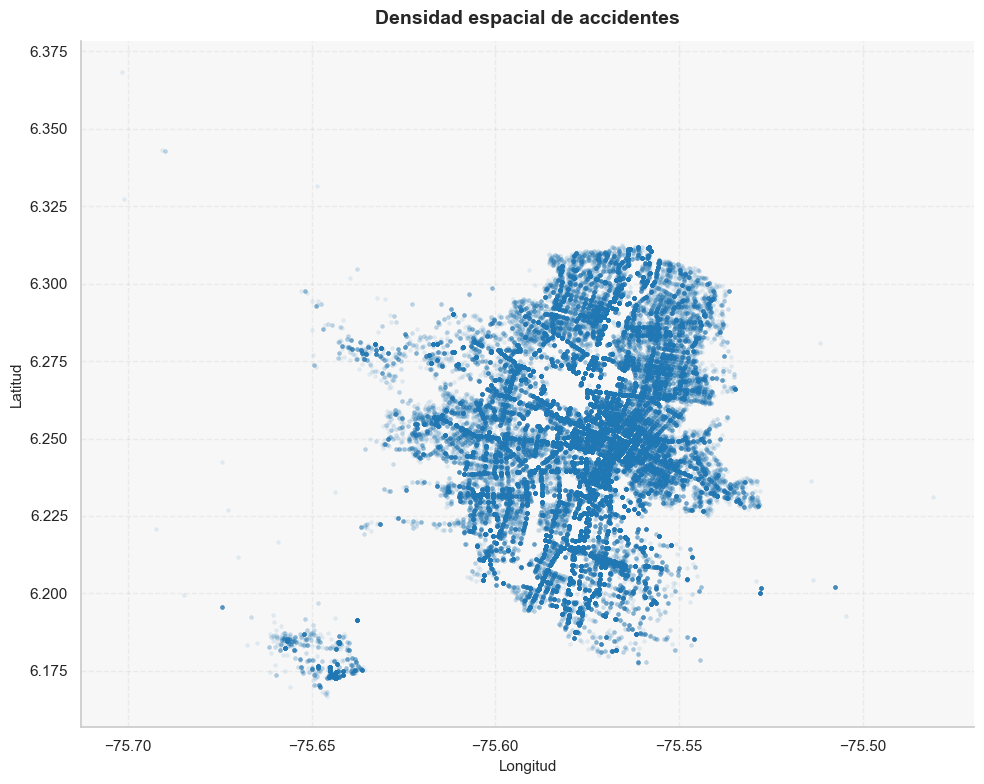

In [10]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#f7f7f7")

sns.scatterplot(
    data=raw_accidentes,
    x="Lon",
    y="Lat",
    s=8,
    alpha=0.1,
    color="#1f77b4",
    edgecolor=None,
    ax=ax
)

ax.set_title("Densidad espacial de accidentes", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)

ax.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

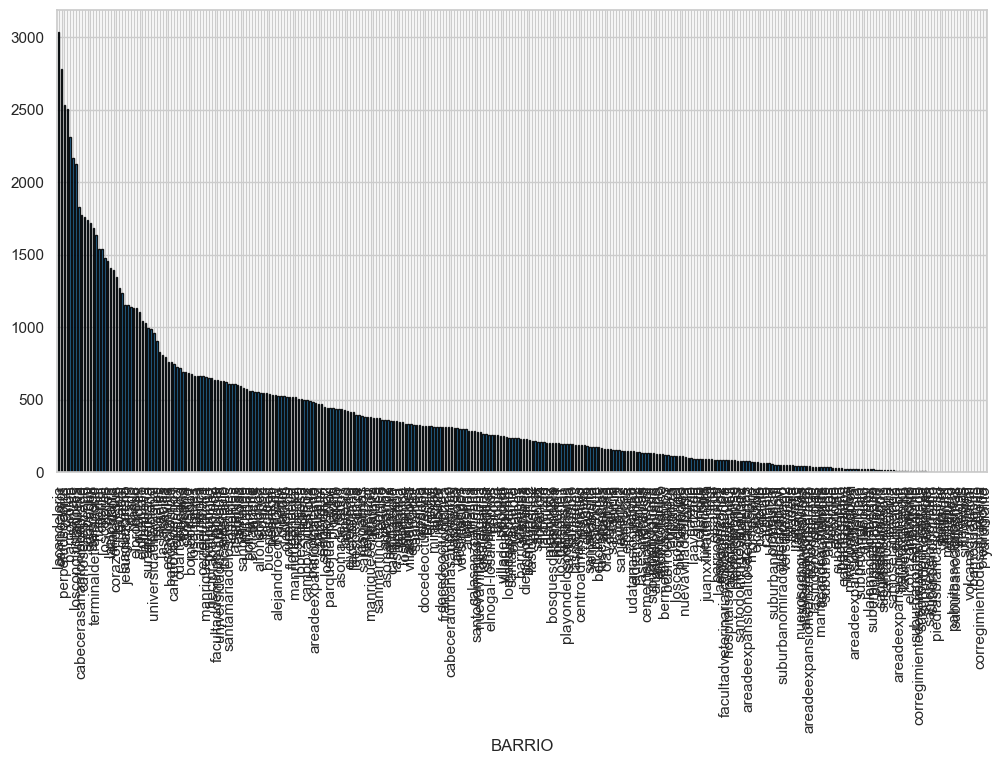

In [11]:
raw_accidentes['BARRIO'].value_counts().plot(kind='bar', color='#1f77b4', edgecolor='black', alpha=0.9, figsize=(12, 6))
plt.show()

<Axes: >

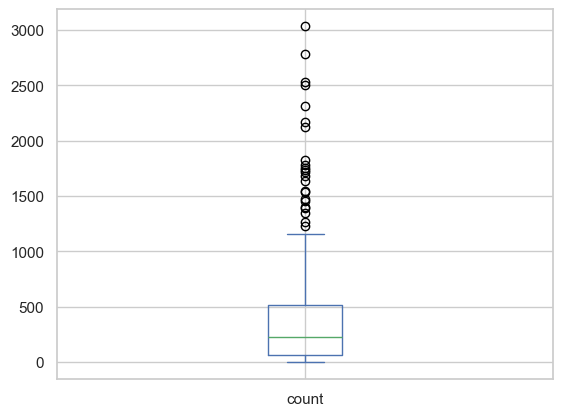

In [12]:
raw_accidentes['BARRIO'].value_counts().plot.box()

In [13]:
raw_accidentes['TW'] =pd.to_datetime(raw_accidentes['TW'])

In [14]:
raw_accidentes['TW'].describe()

count                           125122
mean     2018-07-06 09:11:47.357618688
min                2017-01-01 00:00:00
25%                2017-09-25 16:00:00
50%                2018-07-04 16:30:00
75%                2019-04-17 10:00:00
max                2019-12-31 23:00:00
Name: TW, dtype: object

In [15]:
promedio_mensual_por_barrio = (
    raw_accidentes
    .set_index('TW')
    .groupby('BARRIO')
    .resample('ME', include_groups=False)
    .size()
    .groupby(level=0)
    .mean()
    .sort_values(ascending=False)
)

promedio_mensual_por_barrio.round(2)

BARRIO
lacandelaria             84.36
campoamor                77.36
perpetuosocorro          70.39
caribe                   69.61
barriocolon              64.17
                         ...  
piedrasblancasrepresa     0.17
sanjosedelamontaña        0.17
elvergel                  0.12
villalilliam              0.12
suburbanopotrerito        0.09
Length: 322, dtype: float64

In [16]:
accidentes = pd.read_sql('SELECT * FROM accidentes', con=engine, parse_dates=['TW'])

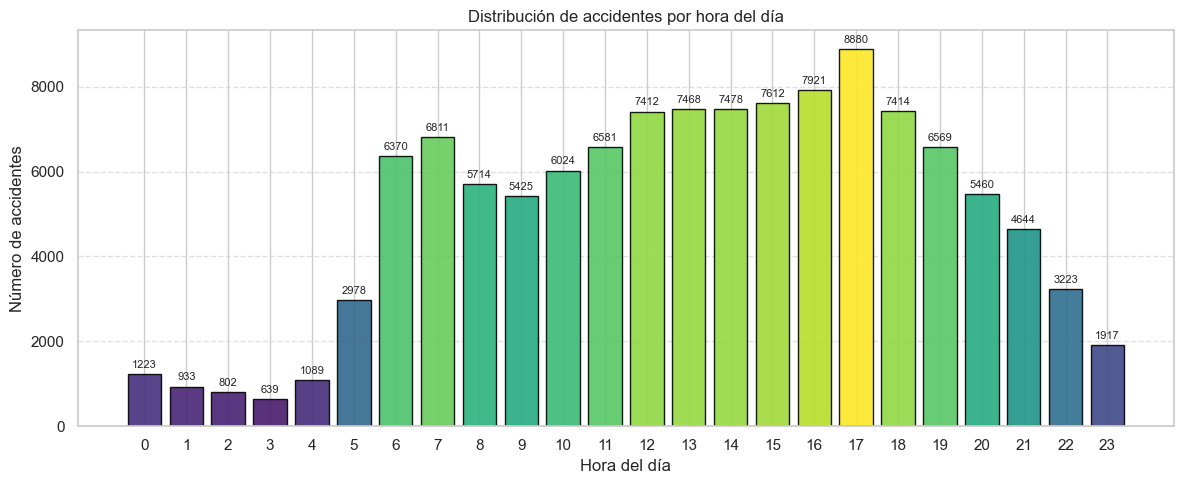

In [17]:
plot_distribucion(
    accidentes,
    columna='Hora',
    titulo='Distribución de accidentes por hora del día',
    xlabel='Hora del día',
    orden=list(range(0, 24))
)

Dado que el datafrme `accidentes` es la fuente natural para la construcción de la variable objetivo, se toma la decisión de crear la columna `es_accidente`

In [18]:
accidentes['es_accidente'] = 1

#### Caracterización del clima

In [19]:
clima = pd.read_sql('SELECT * FROM clima', con=engine, parse_dates=['TW'])

In [20]:
clima.head()

,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,NaN,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


In [21]:
clima.shape

(7991780, 15)

In [22]:
clima.describe()

,TW,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
count,7991780,7.444379e+06,7.444379e+06,7.991170e+06,7.991170e+06,7.991475e+06,7.990865e+06,7.958987e+06,6.959267e+06,7.983830e+06,7.987500e+06,7.987490e+06
mean,2018-06-27 16:13:29.661927168,4.761443e-01,1.595900e-01,1.965380e+01,1.972720e+01,1.433862e+01,7.343608e-01,1.582619e+00,1.113286e+02,7.224333e-01,2.004863e+00,1.131779e+01
min,2017-01-01 00:00:00,0.000000e+00,0.000000e+00,4.510000e+00,4.510000e+00,2.160000e+00,1.700000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.900000e-02
25%,2017-09-26 12:00:00,0.000000e+00,0.000000e+00,1.683000e+01,1.689000e+01,1.300000e+01,6.400000e-01,8.100000e-01,6.200000e+01,5.200000e-01,0.000000e+00,1.000300e+01
50%,2018-06-25 06:00:00,3.020000e-02,6.000000e-02,1.861000e+01,1.871000e+01,1.442000e+01,7.400000e-01,1.360000e+00,9.000000e+01,7.500000e-01,0.000000e+00,1.000300e+01
75%,2019-03-27 15:00:00,6.058000e-01,2.600000e-01,2.252000e+01,2.260000e+01,1.579000e+01,8.500000e-01,2.090000e+00,1.350000e+02,9.000000e-01,4.000000e+00,1.502000e+01
max,2019-12-31 23:00:00,2.082360e+01,1.000000e+00,3.599000e+01,3.806000e+01,2.404000e+01,1.000000e+00,1.526000e+01,3.590000e+02,1.000000e+00,1.400000e+01,1.609300e+01
std,NaN,8.919243e-01,2.195526e-01,3.753267e+00,3.757843e+00,2.032550e+00,1.554380e-01,1.257904e+00,8.104716e+01,2.079337e-01,2.870109e+00,3.397533e+00


In [23]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991780 entries, 0 to 7991779
Data columns (total 15 columns):
 #   Column               Dtype         
---  ------               -----         
 0   TW                   datetime64[ns]
 1   BARRIO               object        
 2   summary              object        
 3   icon                 object        
 4   precipIntensity      float64       
 5   precipProbability    float64       
 6   temperature          float64       
 7   apparentTemperature  float64       
 8   dewPoint             float64       
 9   humidity             float64       
 10  windSpeed            float64       
 11  windBearing          float64       
 12  cloudCover           float64       
 13  uvIndex              float64       
 14  visibility           float64       
dtypes: datetime64[ns](1), float64(11), object(3)
memory usage: 914.6+ MB


In [24]:
clima.isna().sum()

TW                           0
BARRIO                       0
summary                 548641
icon                    548641
precipIntensity         547401
precipProbability       547401
temperature                610
apparentTemperature        610
dewPoint                   305
humidity                   915
windSpeed                32793
windBearing            1032513
cloudCover                7950
uvIndex                   4280
visibility                4290
dtype: int64

Se sabe que algunas columnas del dataframe `clima`, tiene nulos.

In [25]:
min_max_dates = clima.groupby('BARRIO').agg({'TW':['min','max']})
min_max_dates


TW                    
                           min                 max
BARRIO                                            
aguasfrias          2017-01-01 2019-12-31 23:00:00
aldeapablovi        2017-01-01 2019-12-31 23:00:00
alejandria          2017-01-01 2019-12-31 23:00:00
alejandroechavarria 2017-01-01 2019-12-31 23:00:00
alfonsolopez        2017-01-01 2019-12-31 23:00:00
...                        ...                 ...
villanueva          2017-01-01 2019-12-31 23:00:00
villatina           2017-01-01 2019-12-31 23:00:00
villaturbay         2017-01-01 2019-12-31 23:00:00
volcanaguayabal     2018-01-01 2018-12-31 23:00:00
yolombo             2017-01-01 2019-12-31 23:00:00

[319 rows x 2 columns]

In [26]:
min_max_dates.value_counts()

(TW, min)   (TW, max)          
2017-01-01  2019-12-31 23:00:00    295
            2017-12-31 23:00:00      9
            2018-12-31 23:00:00      6
2018-01-01  2018-12-31 23:00:00      6
2019-01-01  2019-12-31 23:00:00      3
Name: count, dtype: int64

Con base a la tabla anterior, no todos los `BARRIOS` tiene un histórico completo

In [27]:
clima.set_index('TW', inplace=True)

In [28]:
nulos_temperatura_por_barrio = clima.groupby('BARRIO')['dewPoint'].apply(lambda s: s.isna().sum()).sort_values(ascending=False)

nulos_temperatura_por_barrio

BARRIO
aguasfrias              1
miravalle               1
nuevavilladelaiguana    1
nuevavilladeaburra      1
naranjal                1
                       ..
suburbanopotrerito      0
elvergel                0
suburbanoelplan         0
suburbanochacaltaya     0
piedragorda             0
Name: dewPoint, Length: 319, dtype: int64

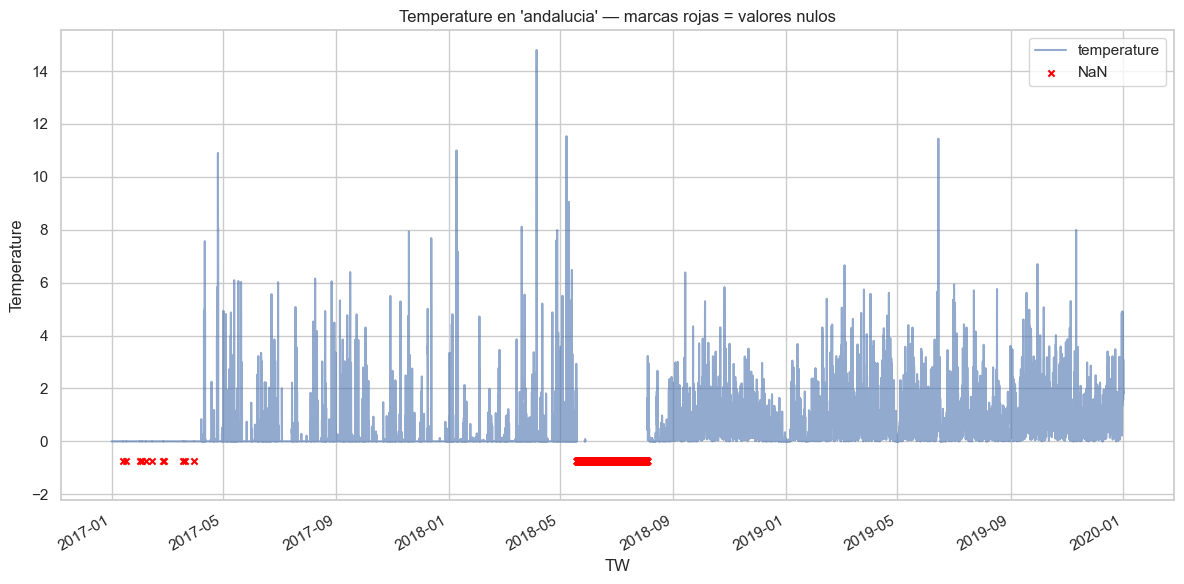

In [29]:
s = clima.loc[clima['BARRIO'] == 'yolombo', 'precipIntensity']
fig, ax = plt.subplots(figsize=(12, 6))
s.plot(ax=ax, alpha=0.6, label='temperature')

na = s[s.isna()]
if not na.empty:
    ymin = s.min()
    ymax = s.max()
    span = (ymax - ymin) if pd.notna(ymax) and pd.notna(ymin) else 1.0
    marker_y = ymin - 0.05 * span
    ax.scatter(na.index, [marker_y] * len(na), color='red', marker='x', s=20, label='NaN')
    ax.set_ylim(marker_y - 0.1 * span, ymax + 0.05 * span)

ax.set_title("Temperature en 'andalucia' — marcas rojas = valores nulos")
ax.set_xlabel("TW")
ax.set_ylabel("Temperature")
ax.legend()
plt.tight_layout()
plt.show()

Valores nulos en 'temperature' para 'yolombo': 2


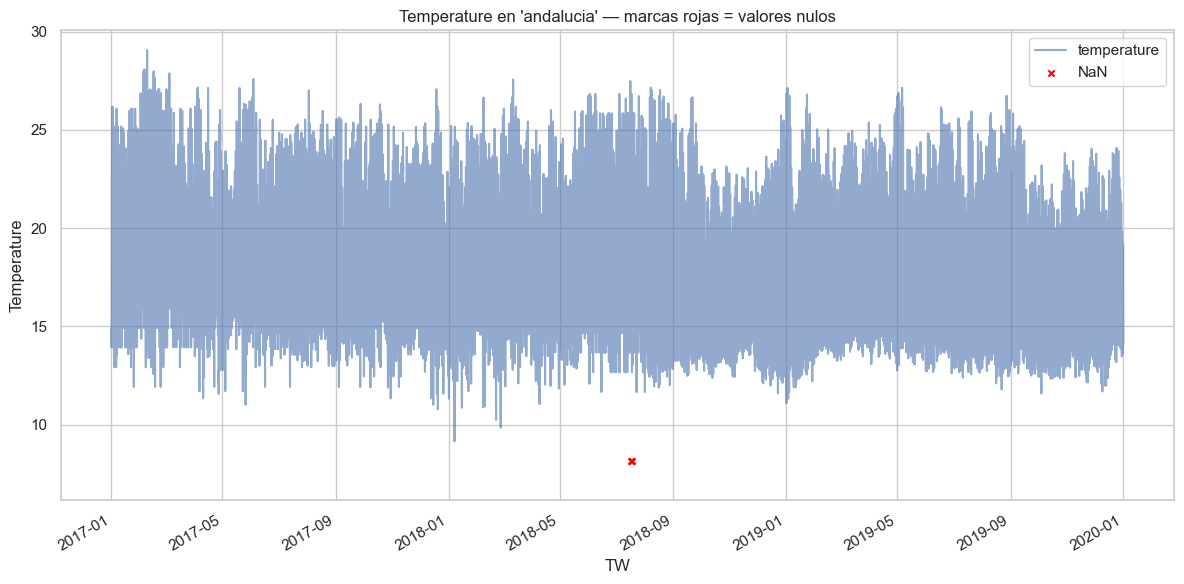

In [30]:
s = clima.loc[clima['BARRIO'] == 'yolombo', 'temperature']
fig, ax = plt.subplots(figsize=(12, 6))
s.plot(ax=ax, alpha=0.6, label='temperature')

na = s[s.isna()]
print(f"Valores nulos en 'temperature' para 'yolombo': {len(na)}")
if not na.empty:
    ymin = s.min()
    ymax = s.max()
    span = (ymax - ymin) if pd.notna(ymax) and pd.notna(ymin) else 1.0
    marker_y = ymin - 0.05 * span
    ax.scatter(na.index, [marker_y] * len(na), color='red', marker='x', s=20, label='NaN')
    ax.set_ylim(marker_y - 0.1 * span, ymax + 0.05 * span)

ax.set_title("Temperature en 'andalucia' — marcas rojas = valores nulos")
ax.set_xlabel("TW")
ax.set_ylabel("Temperature")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
full_df = clima.merge(accidentes, left_on=['TW','BARRIO'], right_on=['TW','BARRIO'], how='left')

In [32]:
full_df['es_accidente'] = full_df['es_accidente'].fillna(0)

In [33]:
full_df.select_dtypes(include='number').corr()

,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility,Lat,Lon,Mes,Dia,Hora,es_accidente
precipIntensity,1.000000,0.610636,-0.048202,-0.037588,0.315403,0.236961,-0.043389,-0.010205,0.365042,-0.122503,0.089346,-0.010698,0.028311,0.139764,-0.017278,0.176208,0.002750
precipProbability,0.610636,1.000000,-0.192027,-0.184167,0.176288,0.293199,-0.162265,0.025215,0.378557,-0.194088,0.021857,0.010839,0.031309,0.182139,-0.040457,0.102915,-0.006874
temperature,-0.048202,-0.192027,1.000000,0.999359,0.239841,-0.836758,0.613845,-0.002064,-0.218520,0.729309,0.107421,-0.086447,-0.047593,-0.082902,-0.007204,0.215072,0.062027
apparentTemperature,-0.037588,-0.184167,0.999359,1.000000,0.262229,-0.822212,0.612379,-0.003263,-0.207161,0.730389,0.113980,-0.088046,-0.049287,-0.080895,-0.006657,0.214765,0.062154
dewPoint,0.315403,0.176288,0.239841,0.262229,1.000000,0.306543,0.083067,-0.043988,0.386254,0.204575,0.280462,-0.026947,-0.016600,0.030509,0.003742,0.042291,0.023390
humidity,0.236961,0.293199,-0.836758,-0.822212,0.306543,1.000000,-0.525322,-0.029250,0.434725,-0.594841,0.086547,0.060132,0.031617,0.090142,0.005671,-0.187112,-0.048220
windSpeed,-0.043389,-0.162265,0.613845,0.612379,0.083067,-0.525322,1.000000,-0.098966,-0.231726,0.364314,0.063927,-0.093136,-0.025981,-0.150402,0.010407,0.264498,0.037464
windBearing,-0.010205,0.025215,-0.002064,-0.003263,-0.043988,-0.029250,-0.098966,1.000000,-0.007861,0.082325,-0.110271,-0.014564,-0.023305,0.020585,-0.008616,-0.036366,0.002280
cloudCover,0.365042,0.378557,-0.218520,-0.207161,0.386254,0.434725,-0.231726,-0.007861,1.000000,-0.196649,0.238082,0.048263,0.042661,0.133750,0.014539,-0.052349,-0.006788
uvIndex,-0.122503,-0.194088,0.729309,0.730389,0.204575,-0.594841,0.364314,0.082325,-0.196649,1.000000,0.118760,-0.067018,-0.018134,-0.010326,-0.003688,-0.167516,0.033479


In [34]:
full_df.columns

Index(['TW', 'BARRIO', 'summary', 'icon', 'precipIntensity',
       'precipProbability', 'temperature', 'apparentTemperature', 'dewPoint',
       'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex',
       'visibility', 'Lat', 'Lon', 'Dia_sem', 'Mes', 'Dia', 'Hora',
       'es_accidente'],
      dtype='object')

In [35]:
full_df.drop(['humidity','apparentTemperature','Lat','Lon','Dia_sem','Mes','Dia','Hora', 'summary'], axis=1, inplace=True)

In [36]:
barrios_accidentes = set(accidentes['BARRIO'].dropna().unique())
barrios_clima = set(clima['BARRIO'].dropna().unique())

solo_en_accidentes = barrios_accidentes - barrios_clima
solo_en_clima = barrios_clima - barrios_accidentes

print("Solo en accidentes:", sorted(solo_en_accidentes))
print("Solo en clima:", sorted(solo_en_clima))

Solo en accidentes: ['elastillero', 'suburbanoaguasfrias', 'yarumalito']
Solo en clima: []


In [37]:
full_df.columns

Index(['TW', 'BARRIO', 'icon', 'precipIntensity', 'precipProbability',
       'temperature', 'dewPoint', 'windSpeed', 'windBearing', 'cloudCover',
       'uvIndex', 'visibility', 'es_accidente'],
      dtype='object')

In [38]:
full_df.head()

,TW,BARRIO,icon,precipIntensity,precipProbability,temperature,dewPoint,windSpeed,windBearing,cloudCover,uvIndex,visibility,es_accidente
0,2017-01-01 00:00:00,aguasfrias,partly-cloudy-night,0.0,0.0,16.43,14.0,1.50,0.0,0.44,0.0,6.004,0.0
1,2017-01-01 01:00:00,aguasfrias,partly-cloudy-night,0.0,0.0,16.43,14.0,1.50,0.0,0.44,0.0,6.004,0.0
2,2017-01-01 02:00:00,aguasfrias,fog,0.0,0.0,15.43,13.0,1.02,NaN,0.44,0.0,2.997,0.0
3,2017-01-01 03:00:00,aguasfrias,fog,0.0,0.0,15.43,13.0,2.09,140.0,0.44,0.0,0.199,0.0
4,2017-01-01 04:00:00,aguasfrias,fog,0.0,0.0,15.43,13.0,2.09,350.0,1.00,0.0,0.099,0.0


In [39]:
full_df.isna().sum()

TW                         0
BARRIO                     0
icon                  548641
precipIntensity       547401
precipProbability     547401
temperature              610
dewPoint                 305
windSpeed              32793
windBearing          1032513
cloudCover              7950
uvIndex                 4280
visibility              4290
es_accidente               0
dtype: int64

In [40]:
full_df.drop(['windBearing', 'precipProbability', 'windSpeed', 'uvIndex'], axis=1,inplace=True)

In [41]:
full_df.isna().sum()

TW                      0
BARRIO                  0
icon               548641
precipIntensity    547401
temperature           610
dewPoint              305
cloudCover           7950
visibility           4290
es_accidente            0
dtype: int64

In [42]:
full_df.head()

,TW,BARRIO,icon,precipIntensity,temperature,dewPoint,cloudCover,visibility,es_accidente
0,2017-01-01 00:00:00,aguasfrias,partly-cloudy-night,0.0,16.43,14.0,0.44,6.004,0.0
1,2017-01-01 01:00:00,aguasfrias,partly-cloudy-night,0.0,16.43,14.0,0.44,6.004,0.0
2,2017-01-01 02:00:00,aguasfrias,fog,0.0,15.43,13.0,0.44,2.997,0.0
3,2017-01-01 03:00:00,aguasfrias,fog,0.0,15.43,13.0,0.44,0.199,0.0
4,2017-01-01 04:00:00,aguasfrias,fog,0.0,15.43,13.0,1.00,0.099,0.0


In [43]:
full_df['icon'].value_counts()

icon
partly-cloudy-day      2402048
rain                   1985371
partly-cloudy-night    1776326
cloudy                 1003630
clear-day               162889
fog                      65713
clear-night              47100
wind                        62
Name: count, dtype: int64

In [44]:
full_df['imputed_icon'] = full_df.groupby('BARRIO')['icon'].transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]))

In [45]:
full_df['imputed_precipIntensity'] = full_df.groupby(['BARRIO'])['precipIntensity'].transform(lambda x: x.fillna(x.mean()))

In [46]:
full_df.dropna(subset=['temperature'], inplace=True)

In [47]:
full_df.drop(columns=['icon', 'precipIntensity'], inplace=True)

In [48]:
full_df.isna().sum()

TW                            0
BARRIO                        0
temperature                   0
dewPoint                    305
cloudCover                 7950
visibility                 4290
es_accidente                  0
imputed_icon                  0
imputed_precipIntensity       0
dtype: int64

In [49]:
full_df.head()

,TW,BARRIO,temperature,dewPoint,cloudCover,visibility,es_accidente,imputed_icon,imputed_precipIntensity
0,2017-01-01 00:00:00,aguasfrias,16.43,14.0,0.44,6.004,0.0,partly-cloudy-night,0.0
1,2017-01-01 01:00:00,aguasfrias,16.43,14.0,0.44,6.004,0.0,partly-cloudy-night,0.0
2,2017-01-01 02:00:00,aguasfrias,15.43,13.0,0.44,2.997,0.0,fog,0.0
3,2017-01-01 03:00:00,aguasfrias,15.43,13.0,0.44,0.199,0.0,fog,0.0
4,2017-01-01 04:00:00,aguasfrias,15.43,13.0,1.00,0.099,0.0,fog,0.0


In [50]:
full_df.dropna(inplace=True)

In [51]:
# full_df['imputed_cloudCover'] = full_df.groupby(['BARRIO'])['cloudCover'].transform(lambda x: x.fillna(x.mean()))
# full_df['imputed_dewPoint'] = full_df.groupby(['BARRIO'])['dewPoint'].transform(lambda x: x.fillna(x.mean()))
# full_df['imputed_visibility'] = full_df.groupby(['BARRIO'])['visibility'].transform(lambda x: x.fillna(x.mean()))

In [52]:
full_df.corr(numeric_only=True)

,temperature,dewPoint,cloudCover,visibility,es_accidente,imputed_precipIntensity
temperature,1.000000,0.240379,-0.218519,0.107536,0.062032,-0.046104
dewPoint,0.240379,1.000000,0.386184,0.280431,0.023391,0.309024
cloudCover,-0.218519,0.386184,1.000000,0.238074,-0.006780,0.351379
visibility,0.107536,0.280431,0.238074,1.000000,0.003622,0.087542
es_accidente,0.062032,0.023391,-0.006780,0.003622,1.000000,0.002709
imputed_precipIntensity,-0.046104,0.309024,0.351379,0.087542,0.002709,1.000000


In [53]:
full_df['es_accidente'].value_counts()

es_accidente
0.0    7862565
1.0     120350
Name: count, dtype: int64

In [54]:
cuenta_accidentes = full_df.groupby('BARRIO')['es_accidente'].value_counts().unstack().assign(desbalance=lambda df: (1-(df[1] / df[0]))*100)

<Axes: >

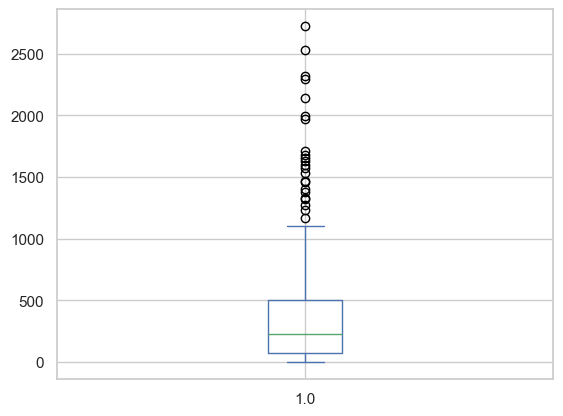

In [55]:
cuenta_accidentes[1].plot.box()

In [56]:
cuenta_accidentes[1].describe()

count     319.000000
mean      377.272727
std       462.248005
min         1.000000
25%        72.500000
50%       231.000000
75%       506.000000
max      2723.000000
Name: 1.0, dtype: float64

<Axes: ylabel='Frequency'>

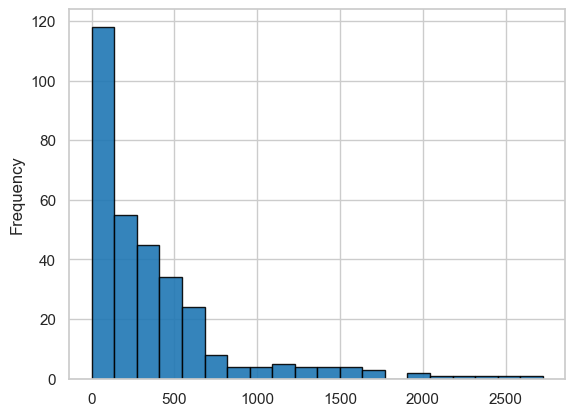

In [57]:
cuenta_accidentes[1].plot.hist(bins=20, color='#1f77b4', edgecolor='black', alpha=0.9)

<Axes: ylabel='Frequency'>

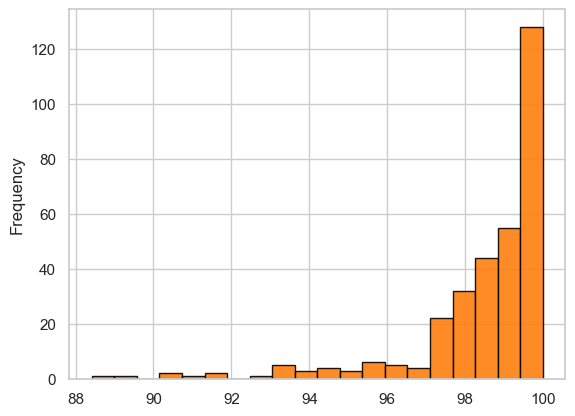

In [58]:
cuenta_accidentes['desbalance'].plot.hist(bins=20, color='#ff7f0e', edgecolor='black', alpha=0.9)

In [59]:
barrios_excluidos =cuenta_accidentes[cuenta_accidentes[1] != 1].index

In [60]:
full_df = full_df[full_df['BARRIO'].isin(barrios_excluidos)]

In [61]:
full_df.corr(numeric_only=True)

,temperature,dewPoint,cloudCover,visibility,es_accidente,imputed_precipIntensity
temperature,1.000000,0.232916,-0.220259,0.106678,0.061492,-0.046062
dewPoint,0.232916,1.000000,0.389218,0.282714,0.022700,0.311546
cloudCover,-0.220259,0.389218,1.000000,0.238213,-0.006961,0.351483
visibility,0.106678,0.282714,0.238213,1.000000,0.003388,0.087875
es_accidente,0.061492,0.022700,-0.006961,0.003388,1.000000,0.002598
imputed_precipIntensity,-0.046062,0.311546,0.351483,0.087875,0.002598,1.000000


In [62]:
full_df.shape

(7895597, 9)

In [63]:
barrios_dummies = pd.get_dummies(full_df['BARRIO'], prefix='barrio').astype(int)

In [64]:
barrios_dummies.to_parquet('barrios_dummies.parquet', index=False)

In [67]:
full_df.duplicated(subset=['TW','BARRIO'], keep=False).sum()

np.int64(0)

In [68]:
full_df.to_parquet('full_df.parquet', index=False)